# AI Safety Menu: the 12-month model

**35 numerical estimates, with executable calculations and evidence boundaries.** Positive days close the U.S. technical capability lead; negative days widen it. Existing nonpublic models count as technical capability. Launch restrictions affect the production of future capability and foreign access rather than erasing a trained model.

This notebook recomputes the headline model locally. The more expensive structural sensitivity runs are supplied as saved results from `model/run_all.py`. They can be regenerated with that script. No private data, paid API or network request is needed.

Most policy-specific causal parameters are explicit analyst priors. This is a structural estimate under those priors, **not an empirically identified policy effect**. See [METHOD](METHOD.html), [all 35 info pages](index.html), and the [evidence register](sources.html).

In [1]:
from pathlib import Path
import sys, json, hashlib
sys.dont_write_bytecode = True
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
MODEL = ROOT / "model"
sys.path.insert(0, str(MODEL))
from unified_model import make_inputs, evaluate
N, SEED = 8192, 260925
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
records = json.loads((ROOT / "policy-estimates.json").read_text())["policies"]
names = {p["policy_id"]: p["name"] for p in records}
print(f"Run: {N:,} shared parameter draws, seed {SEED}, weekly paths, three-year sensitivity horizon.")

Run: 8,192 shared parameter draws, seed 260925, weekly paths, three-year sensitivity horizon.


## 1. Observations used for calibration

The release table has eight models but only six release campaigns. Some campaign members share evaluations, so they are not independent evidence. Only four campaigns supply a usable access-to-release measure; the GPT-5.5 testing start is a conservative proxy for earliest access. Missing planned-release dates prevent causal measurement of evaluation-induced delay.

In [2]:
release = pd.read_csv(MODEL / "public-release-cases.csv")
assert release.case_id.is_unique and len(release) == 8
assert release.release_cluster.nunique() == 6
assert release.causal_policy_delay_days.isna().all()
display(release[["model", "release_cluster", "public_release_date", "access_start_date",
                 "calendar_access_to_release_days", "observed_access_window_value",
                 "observed_access_window_unit"]].fillna("Not published"))
print("No observed access interval is relabeled as a causal policy delay.")

,model,release_cluster,public_release_date,access_start_date,calendar_access_to_release_days,observed_access_window_value,observed_access_window_unit
0,o1-preview,o1_20240912,2024-09-12,2024-09-03,9.0,9,calendar_days
1,o1-mini,o1_20240912,2024-09-12,2024-08-28,15.0,15,calendar_days
2,o3,o3_o4_20250416,2025-04-16,Not published,21.0,3,weeks
3,o4-mini,o3_o4_20250416,2025-04-16,Not published,21.0,3,weeks
4,GPT-5 thinking,gpt5_20250807,2025-08-07,2025-07-10,28.0,28,calendar_days
5,GPT-5.5,gpt55_20260423,2026-04-23,2026-04-02,21.0,7,calendar_days_elapsed
6,GPT-6 Astra,astra_20260903,2026-09-03,Not published,Not published,3,days_unspecified
7,Claude Opus5.5,opus55_20260922,2026-09-22,Not published,Not published,10,business_days


No observed access interval is relabeled as a causal policy delay.


The ECI trend is a descriptive crosscheck. It is not used to identify the policy effects. The frozen source table ends in June 2026; it is not the live September frontier. A linear scale conversion cancels when applied to both capability shocks and the progress ruler. The separate fixed-6.5-ECI/log-compute sensitivity deliberately changes that mapping.

In [3]:
eci = pd.read_csv(MODEL / "eci_reasoning_frontier.csv")
print(eci.columns.tolist())
display(eci.head(3))
fit = json.loads((MODEL / "baseline_fit.json").read_text())
print(json.dumps({k:fit[k] for k in ["n", "ols_eci_per_year", "rmse_eci", "expanding_window_n", "expanding_window_mae_eci"]}, indent=2))

['model', 'organization', 'release_date', 'eci', 'eci_ci_low', 'eci_ci_high', 'source', 'snapshot_publication']


,model,organization,release_date,eci,eci_ci_low,eci_ci_high,source,snapshot_publication
0,o1-mini,OpenAI,2024-09-12,136.64,132.97,138.02,https://epoch.ai/data-insights/eci-frontier-trend,2026-09-01
1,o1,OpenAI,2024-12-17,142.67,140.92,143.72,https://epoch.ai/data-insights/eci-frontier-trend,2026-09-01
2,Gemini 2.5 Pro (Mar 2025),Google DeepMind,2025-03-31,144.63,142.62,147.29,https://epoch.ai/data-insights/eci-frontier-trend,2026-09-01


{
  "n": 13,
  "ols_eci_per_year": 14.1826945717092,
  "rmse_eci": 1.0635762656092056,
  "expanding_window_n": 7,
  "expanding_window_mae_eci": 1.12996200475806
}


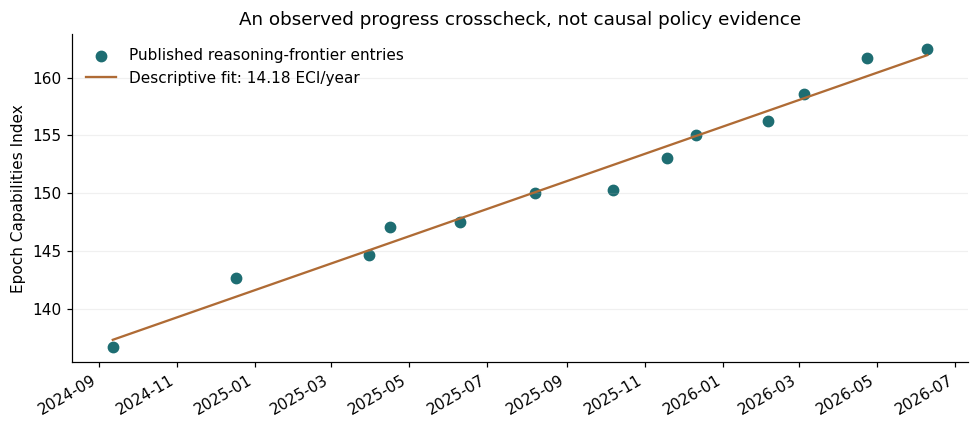

In [4]:
date_col = next(c for c in eci if "date" in c or c == "release")
score_col = next(c for c in eci if "eci" in c.lower() or c.lower() == "score")
dates = pd.to_datetime(eci[date_col])
x = (dates-dates.min()).dt.days.to_numpy()/365.25
y = eci[score_col].to_numpy(dtype=float)
slope, intercept = np.polyfit(x,y,1)
assert abs(slope-fit["ols_eci_per_year"]) < 1e-8
fig,ax=plt.subplots(figsize=(9,4))
ax.scatter(dates,y,color="#1e6d72",s=45,label="Published reasoning-frontier entries")
ax.plot(dates,intercept+slope*x,color="#af6b35",label=f"Descriptive fit: {slope:.2f} ECI/year")
ax.set(ylabel="Epoch Capabilities Index",title="An observed progress crosscheck, not causal policy evidence")
ax.legend(frameon=False);ax.grid(axis="y",alpha=.18)
fig.autofmt_xdate();fig.tight_layout()
fig.savefig(ROOT/"eci-crosscheck.png")
plt.show()

## 2. Recompute all 35 estimates

The production equation has diminishing returns to research and incremental feedback from AI capability. Both countries receive direct input effects and lagged spillovers. A fixed-point iteration includes incoming knowledge changes in research productivity. All comparisons share growth and dependence draws. Bundle gates and workloads are combined before national effects are calculated.

In [5]:
inputs = make_inputs(n=N, seed=SEED, steps=52, years=3)
calculated = evaluate(inputs)
saved = json.loads((MODEL/"model-results.json").read_text())
assert set(calculated["estimates"]) == set(names)
for pid in names:
    r=calculated["estimates"][pid]["1"]
    assert abs(r["mean_days"]-saved["estimates"][pid]["1"]["mean_days"]) < 1e-10
    assert abs(r["us_delay_days"]-r["china_delay_days"]-r["mean_days"]) < 1e-9
    assert abs(r["us_direct_days"]+r["us_research_days"]+r["us_reverse_spillover_days"]-r["us_delay_days"]) < 1e-9
    assert abs(r["china_direct_days"]+r["china_research_days"]+r["china_spillover_days"]-r["china_delay_days"]) < 1e-9
    assert calculated["estimates"][pid]["convergence"]["converged"]
rows=[]
for record in records:
    pid=record["policy_id"];r=calculated["estimates"][pid]["1"]
    rows.append({"Policy":names[pid],"Best estimate, days":r["mean_days"],
                 "5th percentile":r["p05_days"],"95th percentile":r["p95_days"],
                 "US loss":r["us_delay_days"],"China loss":r["china_delay_days"],
                 "MC standard error":r["mc_standard_error_days"]})
prices=pd.DataFrame(rows)
display(prices.style.format(precision=3))
print("All 35 recomputed means match the frozen output; country decompositions reconstruct exactly.")

,Policy,"Best estimate, days",5th percentile,95th percentile,US loss,China loss,MC standard error
0,Critical safety incident reporting,0.000,0.000,0.001,0.000,0.000,0.000
1,Published frontier safety framework,-0.023,-0.110,0.029,0.032,0.055,0.001
2,Transparency report at launch,-0.023,-0.075,0.000,0.004,0.027,0.000
3,Whistleblower protections,0.126,0.011,0.386,0.135,0.010,0.001
4,Full shutdown capability,0.369,0.033,1.143,0.417,0.048,0.004
5,Annual independent compliance audit,-0.005,-0.044,0.021,0.019,0.024,0.000
6,Mandatory internal capability evaluations,-0.032,-0.150,0.026,0.028,0.060,0.001
7,Independent pre-deployment evaluation,-0.041,-0.148,0.010,0.024,0.064,0.001
8,Twenty business days of evaluator access,-0.187,-0.809,0.005,0.052,0.239,0.003
9,Triggered red-team and remediation,0.021,-0.153,0.205,0.147,0.126,0.001


All 35 recomputed means match the frozen output; country decompositions reconstruct exactly.


The intervals below describe uncertainty in conditional expected effects under the input priors. They do not describe every realized history, and are not confidence intervals. Most fine rankings among near-zero measures are not robust.

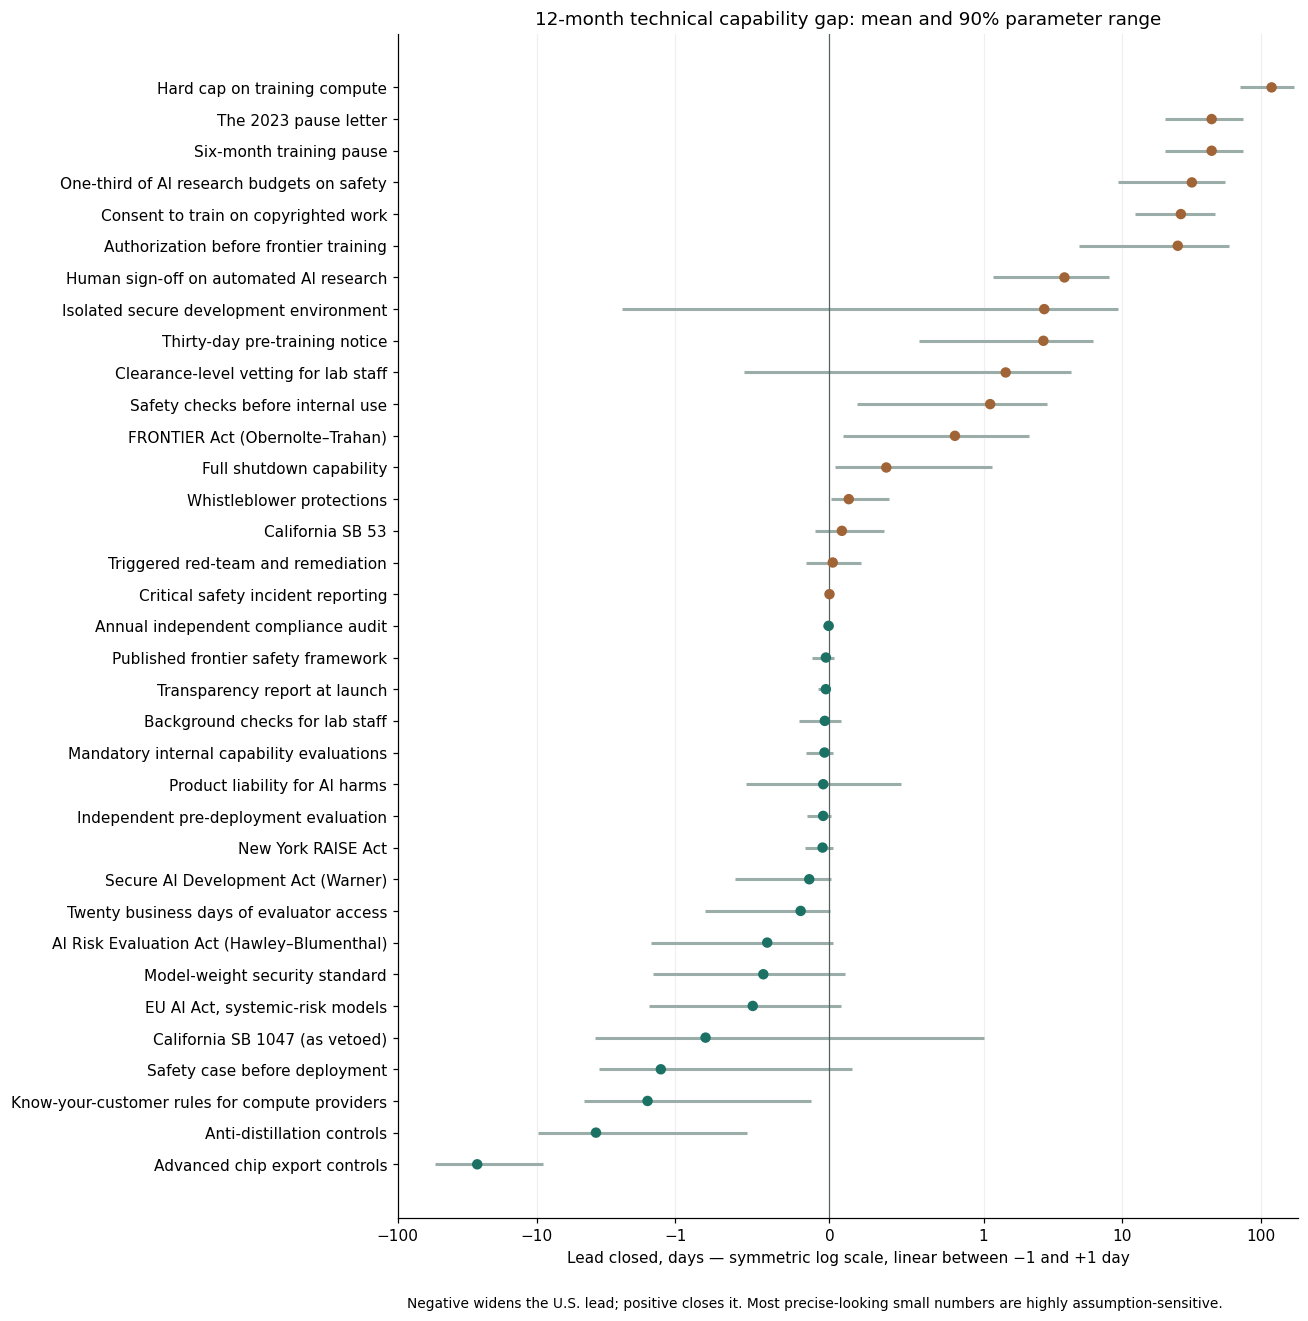

In [6]:
ordered=prices.sort_values("Best estimate, days")
y=np.arange(len(ordered));mid=ordered["Best estimate, days"].to_numpy()
fig,ax=plt.subplots(figsize=(12,12))
ax.hlines(y,ordered["5th percentile"],ordered["95th percentile"],color="#9aada8",lw=2)
ax.scatter(mid,y,c=np.where(mid<0,"#1c7165","#a16437"),s=34,zorder=3)
ax.set_yticks(y,ordered["Policy"])
ax.set_xscale("symlog",linthresh=1,linscale=1)
ax.set_xticks([-100,-10,-1,0,1,10,100],labels=["−100","−10","−1","0","1","10","100"])
ax.axvline(0,color="#53625e",lw=.8);ax.grid(axis="x",alpha=.2)
ax.set(xlabel="Lead closed, days — symmetric log scale, linear between −1 and +1 day",
       title="12-month technical capability gap: mean and 90% parameter range")
ax.text(.01,-.075,"Negative widens the U.S. lead; positive closes it. Most precise-looking small numbers are highly assumption-sensitive.",transform=ax.transAxes,fontsize=9)
fig.tight_layout();fig.savefig(ROOT/"policy-estimates.png",bbox_inches="tight")
plt.show()

## 3. Horizon and structural sensitivity

A fixed input share can create a persistent level gap, a permanent compute ceiling can increasingly bind, and a temporary pause can partly unwind. This is why the 12-month endpoint cannot be replaced by an additive annual delay. The 36-month columns are scenario extensions, with post-year-one inputs held fixed where documented.

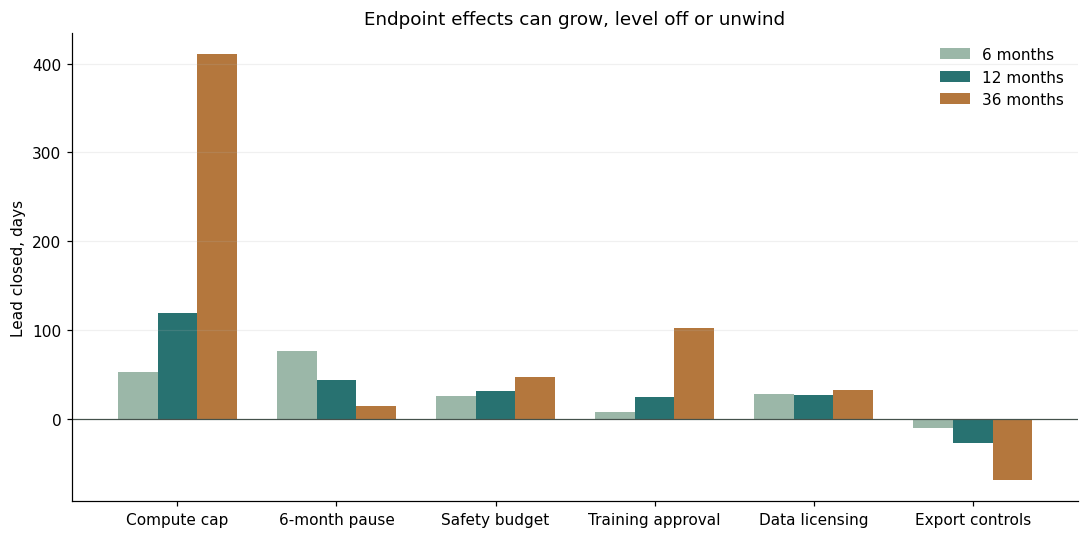

In [7]:
selected=["compute-cap","pause-6","safety-compute-share","safety-case-train","data-licensing","export-controls"]
fig,ax=plt.subplots(figsize=(10,5))
x=np.arange(len(selected));width=.25
for k,(h,label,color) in enumerate([("0.5","6 months","#9bb7a8"),("1","12 months","#287271"),("3","36 months","#b4773d")]):
    vals=[calculated["estimates"][p][h]["mean_days"] for p in selected]
    ax.bar(x+(k-1)*width,vals,width,label=label,color=color)
ax.axhline(0,color="#44514b",lw=.8);ax.grid(axis="y",alpha=.18)
ax.set_xticks(x,["Compute cap","6-month pause","Safety budget","Training approval","Data licensing","Export controls"])
ax.set(ylabel="Lead closed, days",title="Endpoint effects can grow, level off or unwind")
ax.legend(frameon=False);fig.tight_layout();fig.savefig(ROOT/"horizon-sensitivity.png")
plt.show()

In [8]:
sensitivity=json.loads((MODEL/"sensitivity-results.json").read_text())
cols={"Main":None,"No forward reliance":"no_forward_diffusion","Half reliance":"half_forward_diffusion",
      "Double reliance":"double_forward_diffusion","No AI feedback":"no_ai_research_feedback",
      "Alternative ECI ruler":"fixed_6_5_eci_per_log_compute_observed_ruler"}
rows=[]
for pid in names:
    row={"Policy":names[pid]}
    for label,key in cols.items():row[label]=calculated["estimates"][pid]["1"]["mean_days"] if key is None else sensitivity[key][pid]["1"]
    rows.append(row)
display(pd.DataFrame(rows).style.format(precision=2))
print("Universal-pause sensitivity at month12:",sensitivity["universal_pause"]["pause-6"]["1"])
print("It is a separate scenario. Both menu pause headlines retain the menu's unilateral implementation convention.")

,Policy,Main,No forward reliance,Half reliance,Double reliance,No AI feedback,Alternative ECI ruler
0,Critical safety incident reporting,0.00,0.00,0.00,0.00,0.00,0.00
1,Published frontier safety framework,-0.02,0.03,0.00,-0.08,-0.02,-0.03
2,Transparency report at launch,-0.02,0.00,-0.01,-0.05,-0.02,-0.03
3,Whistleblower protections,0.13,0.14,0.13,0.12,0.11,0.16
4,Full shutdown capability,0.37,0.42,0.39,0.32,0.33,0.47
5,Annual independent compliance audit,-0.01,0.02,0.01,-0.03,-0.00,-0.01
6,Mandatory internal capability evaluations,-0.03,0.03,-0.00,-0.09,-0.03,-0.04
7,Independent pre-deployment evaluation,-0.04,0.02,-0.01,-0.10,-0.04,-0.05
8,Twenty business days of evaluator access,-0.19,0.04,-0.07,-0.42,-0.16,-0.24
9,Triggered red-team and remediation,0.02,0.14,0.08,-0.10,0.02,0.03


Universal-pause sensitivity at month12: -3.9678749631120107
It is a separate scenario. Both menu pause headlines retain the menu's unilateral implementation convention.


## 4. Numerical and methodological checks

Implementation checks do not validate the true policy effects. The source evidence, the model structure and the numerical solution are separate layers. The saved validation files describe boundary conditions, an alternative seed and a half-weekly time grid.

In [9]:
validation=json.loads((MODEL/"numerical-validation.json").read_text())
print("Maximum weekly vs half-weekly difference:",validation["max_time_step_difference_days"],"days")
assert validation["max_time_step_difference_days"] < .2
checks=[]
for filename in ["unified-validation.json","production-validation.json","china-path-validation.json","regulation-sampler-validation.json"]:
    data=json.loads((MODEL/filename).read_text())
    print(filename)
    print(str(data)[:1000])
print("Largest MC standard error:",prices["MC standard error"].max(),"days")
print("Largest fixed-point iteration count:",max(x["convergence"]["iterations"] for x in calculated["estimates"].values()))
assert np.isfinite(prices.select_dtypes("number").to_numpy()).all()
assert calculated["estimates"]["pause-6"]["1"]["mean_days"] == calculated["estimates"]["pause-letter"]["1"]["mean_days"]
print("No missing numeric estimates. All bundle and policy identifiers covered.")

Maximum weekly vs half-weekly difference: 0.06849444806655924 days
unified-validation.json
{'checks': [{'check': 'Zero intervention has exactly zero effect', 'passed': True, 'detail': ''}, {'check': 'Half-speed US with no diffusion closes exactly half a year', 'passed': True, 'detail': 182.625}, {'check': 'Symmetric ruler: half-speed China widens by half a year', 'passed': True, 'detail': -182.625}, {'check': 'Equal direct country shocks cancel without spillovers', 'passed': True, 'detail': ''}, {'check': 'Public delay does nothing with zero reliance', 'passed': True, 'detail': ''}, {'check': 'Public-only delay with teacher reliance widens US lead', 'passed': True, 'detail': -2.9772321300891003}, {'check': 'Public-only delay never mechanically delays internal US frontier', 'passed': True, 'detail': ''}, {'check': 'Teacher effect linear in marginal reliance with no feedback', 'passed': True, 'detail': ''}, {'check': 'China dependency reduces unilateral-US restriction gap closure', 'pass

## Reading the result correctly

The strongest numerical changes concern the meaning of a delay. An external launch gate can withhold useful teachers from China while leaving the U.S. technical frontier largely intact. Ordinary paperwork displaces only a small share of a frontier lab's research resources. Training prohibitions directly block new capability production and are much larger under these assumptions.

The model does not establish that the small negative estimates are empirically proven strategic benefits. Their signs depend on marginal foreign reliance and on the technical-frontier definition. The security estimates depend heavily on useful-compromise hazards and retained stolen-model value. Export controls depend on additional purchases after relaxation and the relevance of that compute. These are quantified assumptions, exposed in each info page.

To regenerate the full sensitivity suite: `python model/run_all.py`. To inspect a parameter, open the appropriate calibration JSON and its cited primary source. A complete manifest records file hashes. No changes have been published to the live website.